# S-Fig 2 — Saturation Curves (all heads overlaid)

AUROC vs context length, LSTM / Transformer / MeanPool on the same axes.  
**Source**: analysis.csv (k=all)  
**Tasks**: main tasks

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [4]:
TASKS  = MAIN_TASKS   # 5 tasks → 2-2-1 layout
HEADS  = ["lstm", "transformer", "mean_pool"]
SPLIT  = "test"
FIG_W  = 10.0   # wider than TBME column — ok for supplementary/preview
ROW_H  = 3.0    # inches per row — increase for even bigger panels

df = load_analysis("phase0_v3", split=SPLIT, k="all")

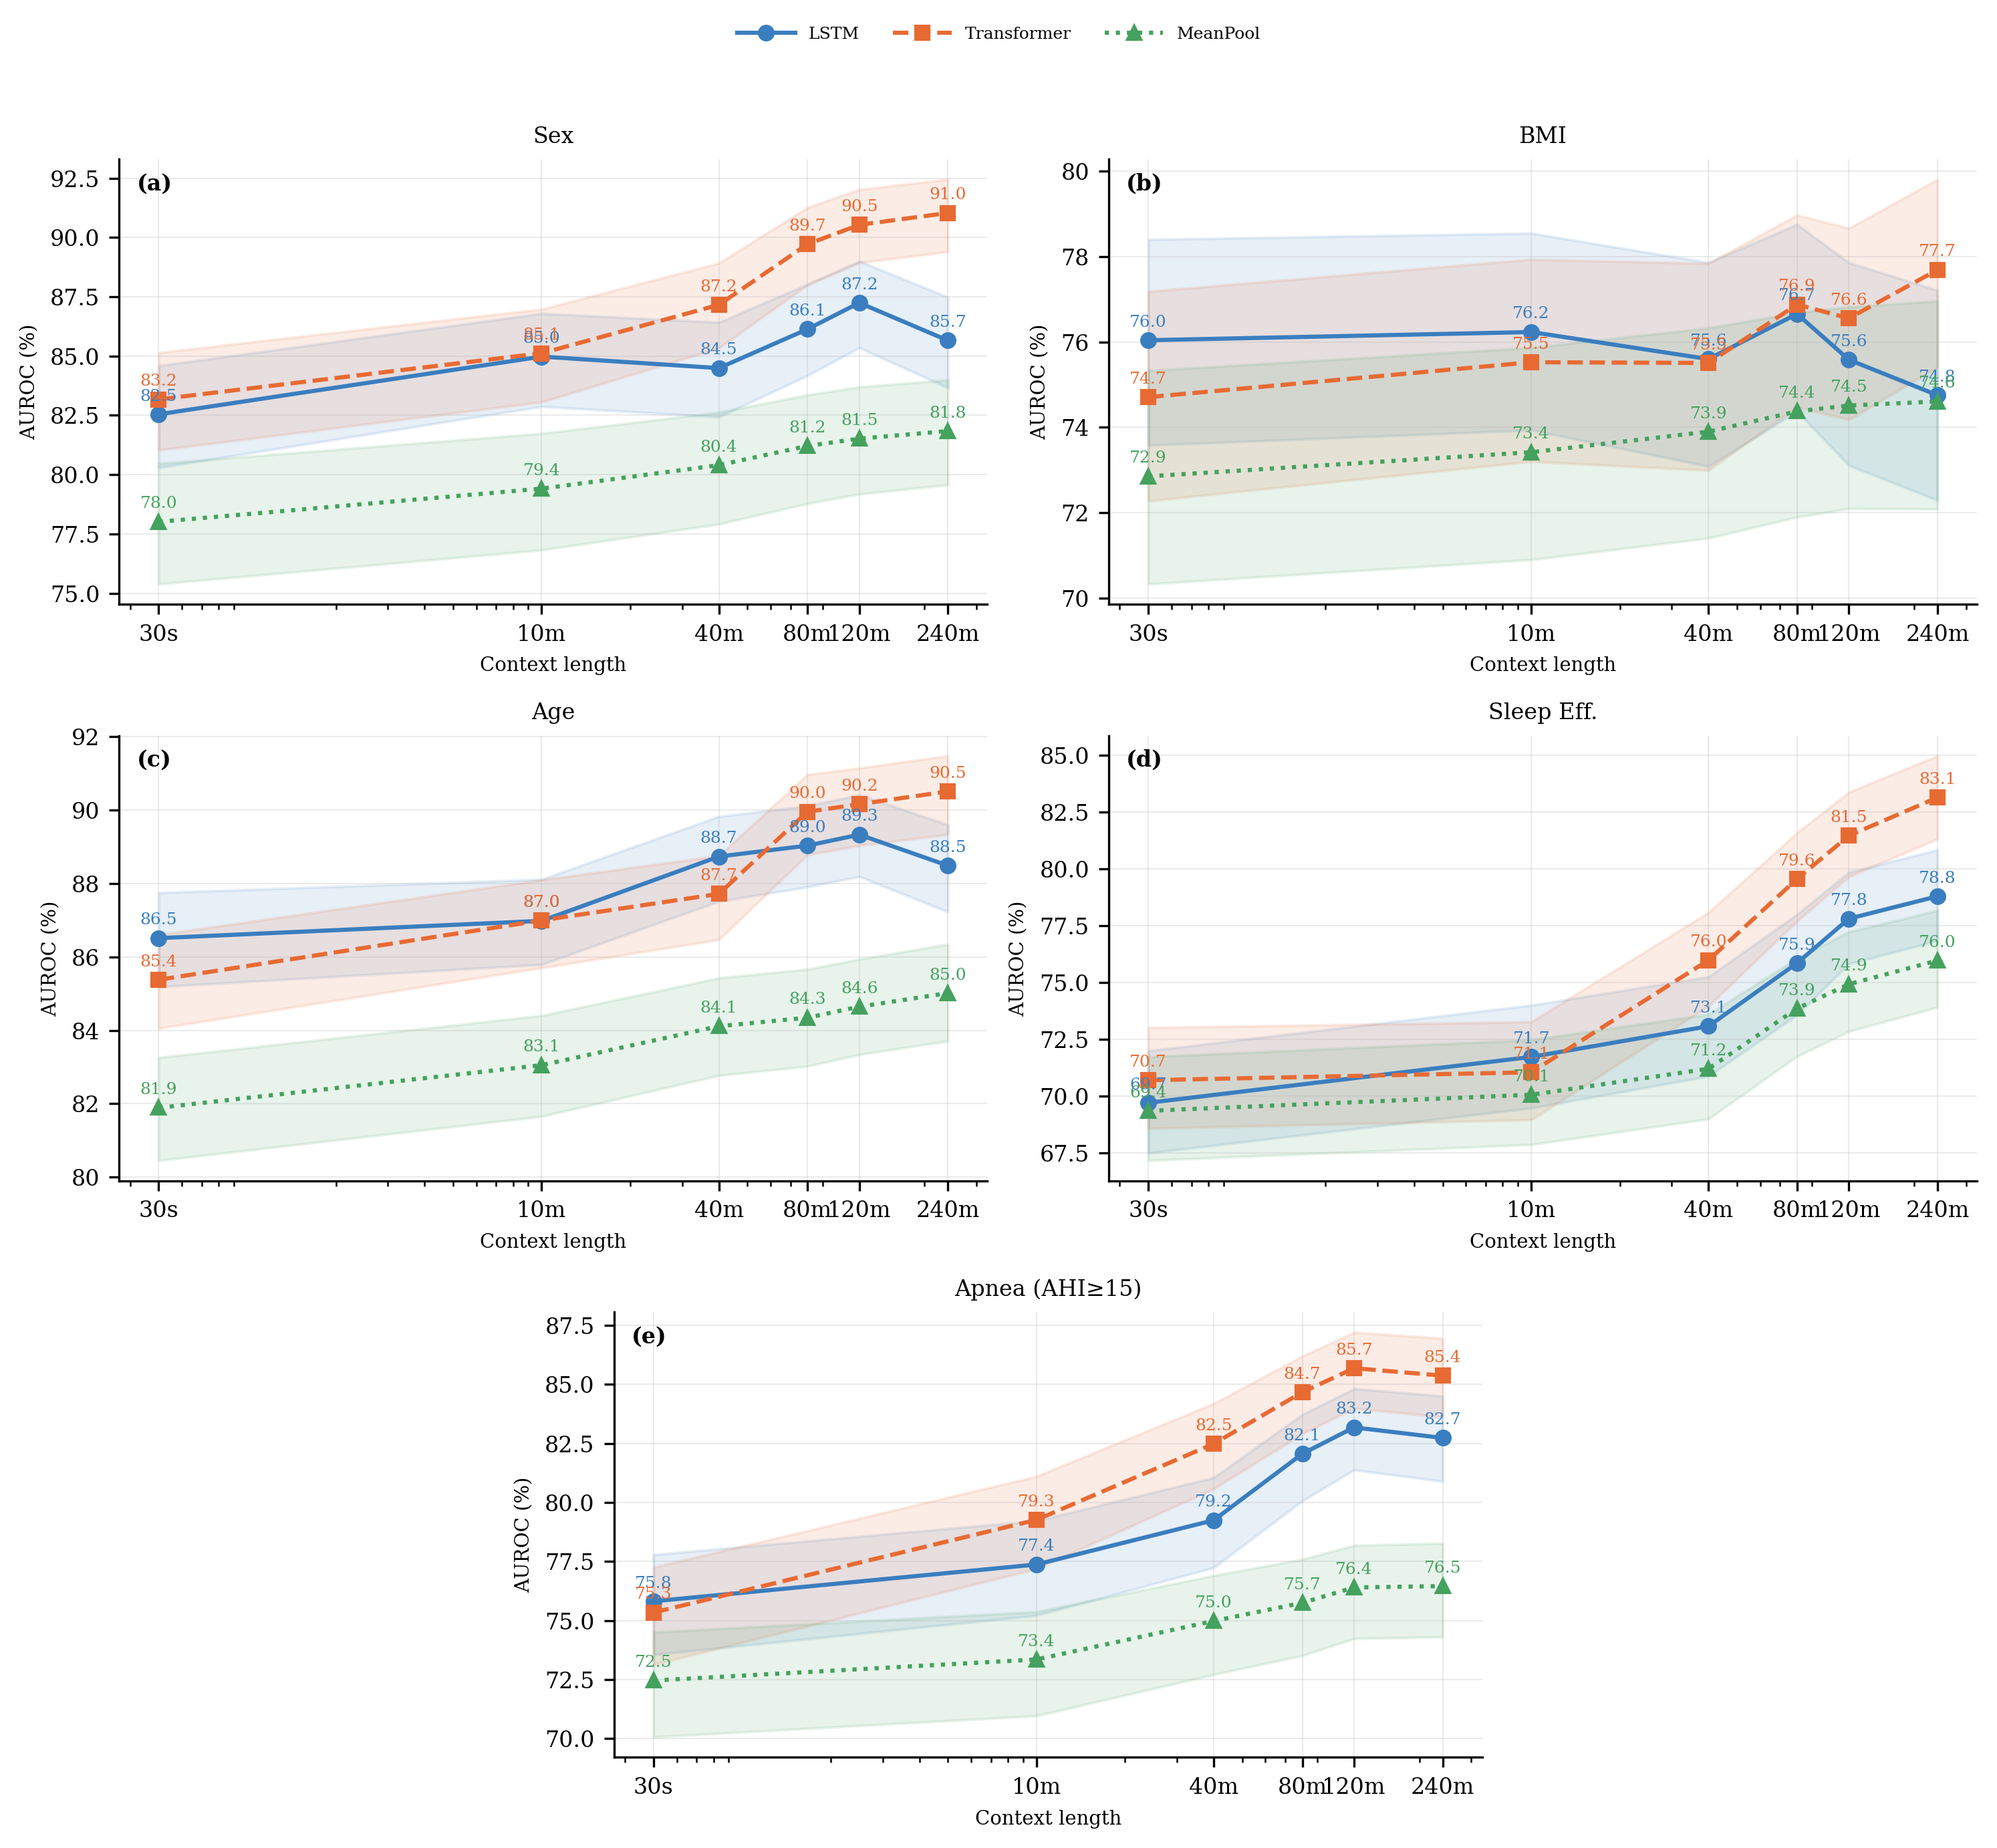

In [5]:
# Mosaic 2-2-1: each label spans 2 virtual columns; "." = empty cell
# a a b b
# c c d d
# . e e .
mosaic = [
    ["a", "a", "b", "b"],
    ["c", "c", "d", "d"],
    [".",  "e", "e", "."],
]
labels = ["a", "b", "c", "d", "e"]

fig, axd = plt.subplot_mosaic(mosaic, figsize=(FIG_W, 3 * ROW_H))

for i, (lbl, task) in enumerate(zip(labels, TASKS)):
    panels.saturation_panel(axd[lbl], df, task, heads=HEADS, show_values=True)
    axd[lbl].set_title(TASK_LABEL[task], fontsize=8)
    add_panel_label(axd[lbl], f"({lbl})")

# Shared legend above the figure
handles, leg_labels = axd["a"].get_legend_handles_labels()
for lbl in labels:
    if axd[lbl].get_legend():
        axd[lbl].get_legend().remove()
fig.legend(handles, leg_labels, loc="upper center", ncol=3,
           fontsize=FONT_ANNOT, bbox_to_anchor=(0.5, 1.02), frameon=False,
           handlelength=3.5)

fig.tight_layout(rect=[0, 0, 1, 0.97], h_pad=1.2, w_pad=1.0)
plt.show()

In [ ]:
# ── Run when figure looks good ──────────────────────────────
save_figure(fig, FINAL_OUT, "sfig2_saturation")
import shutil
shutil.copy(FINAL_OUT / "sfig2_saturation.pdf",
            WORKSPACE_ROOT / "TBME_submission" / "sfig2_saturation.pdf")
print("Saved + copied → TBME_submission/sfig2_saturation.pdf")